# RL Project — Highway-v0
**Core Task**: Custom DQN + Stable-Baselines3 PPO on `highway-v0`  
**Extension**: Double DQN (DDQN) vs vanilla DQN ablation


In [1]:
# !pip install highway_env

In [1]:
import os
import math
import random
import time
import statistics as stats
from collections import namedtuple, deque
from dataclasses import dataclass, asdict
from itertools import count

import gymnasium as gym
import highway_env          # registers highway-v0 with gymnasium
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from shared_core_config import SHARED_CORE_CONFIG, SHARED_CORE_ENV_ID

# IPython display helpers for live plots inside Jupyter
is_ipython = "inline" in matplotlib.get_backend()
if is_ipython:
    from IPython import display
plt.ion()

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps"  if torch.backends.mps.is_available() else
    "cpu"
)
print("device:", device)

device: cpu


## Environment

In [2]:
def make_env(seed: int, render: bool = False) -> gym.Env:
    """Create and seed a highway-v0 environment.

    Args:
        seed:   RNG seed forwarded to env.reset / action_space / obs_space.
        render: When True the env renders offscreen (needed for video recording).
    """
    config = dict(SHARED_CORE_CONFIG)
    render_mode = None
    if render:
        config["offscreen_rendering"] = True
        render_mode = "rgb_array"

    env = gym.make(SHARED_CORE_ENV_ID, config=config, render_mode=render_mode)
    env.reset(seed=seed)
    env.action_space.seed(seed)
    env.observation_space.seed(seed)
    return env

## DQN Configuration

In [3]:
@dataclass
class DQNConfig:
    # ── Replay buffer ──────────────────────────────────────────────────────
    replay_capacity: int  = 15_000  # max transitions stored
    batch_size:      int  = 32      # mini-batch size for each gradient step
    learning_starts: int  = 200     # steps before gradient updates begin

    # ── Discount & target network ──────────────────────────────────────────
    gamma:               float = 0.8   # reward discount factor
    target_update_every: int   = 50    # steps between target-net syncs (hard update)

    # ── ε-greedy exploration schedule ─────────────────────────────────────
    eps_start: float = 1.0    # initial exploration rate
    eps_end:   float = 0.05   # final (minimum) exploration rate
    eps_decay: int   = 5_000  # exponential decay half-life in steps

    # ── Optimiser ──────────────────────────────────────────────────────────
    lr:          float = 5e-4  # AdamW learning rate
    hidden_size: int   = 256   # width of each hidden layer

    # ── Training budget ────────────────────────────────────────────────────
    num_episodes:      int = int(2e4)  # total episodes per seed
    eval_episodes:     int = 25        # episodes used for periodic evaluation
    checkpoint_every:  int = 100       # save a checkpoint every N episodes
    best_avg_window:   int = 20        # window for tracking best checkpoint

## Replay Buffer & Network Architecture

In [4]:
Transition = namedtuple("Transition", ("state", "action", "next_state", "reward"))


class ReplayBuffer:
    """Fixed-size circular buffer of (s, a, s', r) transitions."""

    def __init__(self, capacity: int):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        self.memory.append(Transition(*args))

    def sample(self, batch_size: int):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)


class Net(nn.Module):
    """Two-hidden-layer MLP mapping observations to Q-values.

    Input  : flattened kinematics observation  (vehicles_count × features)
    Output : Q(s, a) for every discrete action
    """

    def __init__(self, n_obs: int, n_actions: int, hidden_size: int = 256):
        super().__init__()
        self.layer1 = nn.Linear(n_obs, hidden_size)
        self.layer2 = nn.Linear(hidden_size, hidden_size)
        self.layer3 = nn.Linear(hidden_size, n_actions)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x)

## Utilities

In [5]:
def set_seed(seed: int):
    """Seed Python random, NumPy, and PyTorch for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def to_state_tensor(obs) -> torch.Tensor:
    """Convert a numpy observation to a (1, n_obs) float tensor on device."""
    return torch.tensor(obs, dtype=torch.float32, device=device).view(1, -1)

In [6]:
RUN_ID         = time.strftime("%Y%m%d-%H%M%S")
print(RUN_ID)
CHECKPOINT_DIR = os.path.join("checkpoints")
print("Checkpoint dir:", CHECKPOINT_DIR)

def save_checkpoint(agent, episode: int, episode_rewards: list, best: bool = False):
    tag  = "best" if best else f"ep_{episode:05d}"
    path = os.path.join("checkpoints", agent.name, f"run_{RUN_ID}",f"{tag}.pt")
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save(
        {
            "policy_state_dict":    agent.policy_net.state_dict(),
            "target_state_dict":    agent.target_net.state_dict(),
            "optimizer_state_dict": agent.optimizer.state_dict(),
            "steps_done":           agent.steps_done,
            "episode":              episode,
            "seed":                 agent.seed,
            "episode_rewards":      episode_rewards,
            "config":               asdict(agent.cfg),
        },
        path,
    )

20260412-120845
Checkpoint dir: checkpoints


## DQN Agent

In [7]:
class DQNAgent:
    """Vanilla DQN agent (Mnih et al., 2015).

    Uses:
    - ε-greedy exploration with exponential decay
    - Experience replay buffer
    - Hard target-network synchronisation every `target_update_every` steps
    - Huber (SmoothL1) loss with gradient clipping
    """

    def __init__(self, env: gym.Env, cfg: DQNConfig, seed: int):
        self.env  = env
        self.cfg  = cfg
        self.seed = seed

        set_seed(seed)

        state, _ = env.reset(seed=seed)
        self.n_observations = int(torch.tensor(state).numel())
        self.n_actions      = env.action_space.n

        self.policy_net = Net(self.n_observations, self.n_actions, cfg.hidden_size).to(device)
        self.target_net = Net(self.n_observations, self.n_actions, cfg.hidden_size).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()  # target net is never trained directly

        self.optimizer  = optim.AdamW(self.policy_net.parameters(), lr=cfg.lr, amsgrad=True)
        self.memory     = ReplayBuffer(cfg.replay_capacity)
        self.steps_done = 0

    # ── Action selection ────────────────────────────────────────────────────

    def select_action(self, state: torch.Tensor) -> torch.Tensor:
        """ε-greedy action: exploit policy_net or explore uniformly."""
        eps = self.cfg.eps_end + (self.cfg.eps_start - self.cfg.eps_end) * \
              math.exp(-self.steps_done / self.cfg.eps_decay)
        self.steps_done += 1

        if random.random() > eps:
            with torch.no_grad():
                return self.policy_net(state).max(1).indices.view(1, 1)
        return torch.tensor([[self.env.action_space.sample()]], device=device, dtype=torch.long)

    # ── One gradient step ───────────────────────────────────────────────────

    def optimize(self):
        """Sample a mini-batch and perform one gradient update on policy_net."""
        if len(self.memory) < max(self.cfg.batch_size, self.cfg.learning_starts):
            return

        transitions = self.memory.sample(self.cfg.batch_size)
        batch = Transition(*zip(*transitions))

        # Mask for non-terminal transitions
        non_final_mask = torch.tensor(
            [s is not None for s in batch.next_state], device=device, dtype=torch.bool
        )
        non_final_next = [s for s in batch.next_state if s is not None]
        non_final_next = torch.cat(non_final_next) if non_final_next else \
                         torch.empty((0, self.n_observations), device=device)

        state_batch  = torch.cat(batch.state)
        action_batch = torch.cat(batch.action)
        reward_batch = torch.cat(batch.reward)

        # Q(s, a) from the policy network
        q_values = self.policy_net(state_batch).gather(1, action_batch)

        # Bootstrap target: r + γ * max_a' Q_target(s', a')
        next_q = torch.zeros(self.cfg.batch_size, device=device)
        with torch.no_grad():
            if non_final_next.numel() > 0:
                next_q[non_final_mask] = self.target_net(non_final_next).max(1).values

        target = (next_q * self.cfg.gamma + reward_batch).unsqueeze(1)

        loss = F.smooth_l1_loss(q_values, target)

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_value_(self.policy_net.parameters(), 100)
        self.optimizer.step()

    # ── Training loop ───────────────────────────────────────────────────────

    def train(self, plot_fn=None):
        """Run full training loop.

        Returns:
            episode_rewards : list of total rewards per episode
            episode_lengths : list of step counts per episode
        """
        episode_rewards  = []
        episode_lengths  = []
        best_avg_reward  = float("-inf")

        for i_episode in range(self.cfg.num_episodes):
            state, _ = self.env.reset(seed=self.seed + i_episode)
            state     = to_state_tensor(state)
            total_r   = 0.0

            for t in count():
                action = self.select_action(state)
                obs, reward, terminated, truncated, _ = self.env.step(action.item())
                total_r += reward

                done       = terminated or truncated
                next_state = None if done else to_state_tensor(obs)

                self.memory.push(state, action, next_state, torch.tensor([reward], device=device))
                state = next_state

                self.optimize()

                if self.steps_done % self.cfg.target_update_every == 0:
                    self.target_net.load_state_dict(self.policy_net.state_dict())

                if done:
                    episode_rewards.append(total_r)
                    episode_lengths.append(t + 1)
                    if plot_fn:
                        plot_fn(episode_rewards)
                    break

            # ── Periodic checkpoint ────────────────────────────────────────
            if (i_episode + 1) % self.cfg.checkpoint_every == 0:
                save_checkpoint(self, i_episode + 1, episode_rewards)

            # ── Best-model checkpoint ──────────────────────────────────────
            if len(episode_rewards) >= self.cfg.best_avg_window:
                window_avg = stats.mean(episode_rewards[-self.cfg.best_avg_window:])
                if window_avg > best_avg_reward:
                    best_avg_reward = window_avg
                    save_checkpoint(self,i_episode + 1, episode_rewards, best=True)


        return episode_rewards, episode_lengths

## Extension — Double DQN (DDQN)

**Hypothesis**: Vanilla DQN overestimates Q-values due to the max operator selecting and evaluating the same network.  
Double DQN (van Hasselt et al., 2016) decouples action *selection* (policy net) from action *evaluation* (target net), reducing this bias.

The only change from vanilla DQN is in the bootstrap target:
- **DQN**  : `y = r + γ · max_a' Q_target(s', a')`
- **DDQN** : `y = r + γ · Q_target(s', argmax_a' Q_policy(s', a'))`


In [8]:
class DDQNAgent(DQNAgent):
    """Double DQN agent — inherits everything from DQNAgent except the Bellman target."""

    def optimize(self):
        if len(self.memory) < max(self.cfg.batch_size, self.cfg.learning_starts):
            return

        transitions = self.memory.sample(self.cfg.batch_size)
        batch = Transition(*zip(*transitions))

        non_final_mask = torch.tensor(
            [s is not None for s in batch.next_state], device=device, dtype=torch.bool
        )
        non_final_next = [s for s in batch.next_state if s is not None]
        non_final_next = torch.cat(non_final_next) if non_final_next else \
                         torch.empty((0, self.n_observations), device=device)

        state_batch  = torch.cat(batch.state)
        action_batch = torch.cat(batch.action)
        reward_batch = torch.cat(batch.reward)

        q_values = self.policy_net(state_batch).gather(1, action_batch)

        next_q = torch.zeros(self.cfg.batch_size, device=device)
        with torch.no_grad():
            if non_final_next.numel() > 0:
                # DDQN: policy_net selects the best action, target_net evaluates it
                best_actions = self.policy_net(non_final_next).max(1).indices.unsqueeze(1)
                next_q[non_final_mask] = self.target_net(non_final_next).gather(1, best_actions).squeeze(1)

        target = (next_q * self.cfg.gamma + reward_batch).unsqueeze(1)
        loss   = F.smooth_l1_loss(q_values, target)

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_value_(self.policy_net.parameters(), 100)
        self.optimizer.step()

## Plotting Utilities

In [9]:
def plot_training(rewards: list, show_result: bool = False):
    """Live training curve with 100-episode rolling average."""
    plt.figure(1)
    t = torch.tensor(rewards, dtype=torch.float)
    plt.clf()
    plt.title("Result" if show_result else "Training…")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.plot(t.numpy(), alpha=0.4, label="per-episode")

    if len(t) >= 100:
        means = t.unfold(0, 100, 1).mean(1)
        pad   = torch.full((99,), float("nan"))
        plt.plot(torch.cat((pad, means)).numpy(), label="100-ep avg")
        plt.legend()

    plt.pause(0.001)
    if is_ipython:
        display.display(plt.gcf())
        if not show_result:
            display.clear_output(wait=True)


def plot_multi_seed(all_rewards: list[list], labels: list[str], title: str = "Training curves"):
    """Overlay training curves for multiple seeds, with shaded std band."""
    fig, ax = plt.subplots(figsize=(10, 4))
    max_ep = max(len(r) for r in all_rewards)
    padded = np.full((len(all_rewards), max_ep), np.nan)
    for i, r in enumerate(all_rewards):
        padded[i, :len(r)] = r

    mean = np.nanmean(padded, axis=0)
    std  = np.nanstd(padded, axis=0)
    xs   = np.arange(max_ep)

    ax.plot(xs, mean, label="mean")
    ax.fill_between(xs, mean - std, mean + std, alpha=0.2, label="±1 std")
    for i, (r, lbl) in enumerate(zip(all_rewards, labels)):
        ax.plot(r, alpha=0.3, linewidth=0.8, label=lbl)

    ax.set_title(title)
    ax.set_xlabel("Episode")
    ax.set_ylabel("Reward")
    ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

## Evaluation

In [10]:
def evaluate_policy(env: gym.Env, policy_net: nn.Module,
                    n_episodes: int, seed_offset: int) -> tuple[float, float, float]:
    """Greedy rollouts — returns (mean_reward, std_reward, mean_length).

    Uses 50 episodes by default (as required by the project spec).
    """
    policy_net.eval()
    rewards, lengths = [], []

    with torch.no_grad():
        for i in range(n_episodes):
            state, _ = env.reset(seed=seed_offset + i)
            state     = to_state_tensor(state)
            total_r   = 0.0

            for t in count():
                action = policy_net(state).max(1).indices.view(1, 1)
                obs, reward, terminated, truncated, _ = env.step(action.item())
                total_r += reward
                done     = terminated or truncated

                if done:
                    rewards.append(total_r)
                    lengths.append(t + 1)
                    break
                state = to_state_tensor(obs)

    policy_net.train()
    return stats.mean(rewards), stats.stdev(rewards), stats.mean(lengths)

## Run Experiments DDQN

The Expriments are done previously, checkpoints are saved to avoid re run the following cell that takes more than 8h ! 

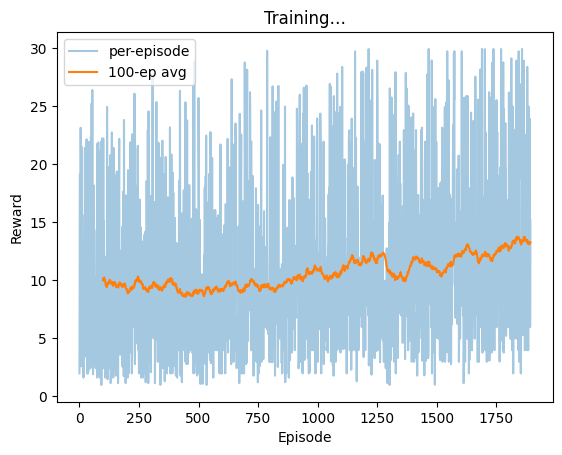

<Figure size 640x480 with 0 Axes>

In [ ]:
# On CPU use a lighter budget; GPU/MPS uses the full config
cfg = DQNConfig() if str(device) == "cpu" else DQNConfig(num_episodes=2000)

#SEEDS = [0, 4, 8, 16]
#SEEDS = [0]  # checkpoints\rl-ddqn\ddqn\run_20260330-213151
#SEEDS = [4]  # checkpoints\rl-ddqn\ddqn\run_20260331-095527
SEEDS = [8]   # checkpoints\rl-ddqn\ddqn\run_20260331-161507

#dqn_results,  dqn_all_rewards  = [], []
ddqn_results, ddqn_all_rewards = [], []

for run_seed in SEEDS:
    print(f"\n{'='*50}\nSeed {run_seed}\n{'='*50}")

    for AgentClass, results_list, rewards_list, label in [
#         (DQNAgent,  dqn_results,  dqn_all_rewards,  "DQN"),
        (DDQNAgent, ddqn_results, ddqn_all_rewards, "DDQN")
    ]:
        env   = make_env(run_seed)
        agent = AgentClass(env, cfg, run_seed)
        agent.name = label.lower()

        print(f"  Training {label}…")
        rewards, lengths = agent.train(plot_fn=plot_training)

        eval_env = make_env(run_seed + 1000)
        mean_r, std_r, mean_len = evaluate_policy(
            eval_env, agent.policy_net, n_episodes=50, seed_offset=run_seed + 2000
        )
        eval_env.close()
        env.close()

        results_list.append({"seed": run_seed, "mean": mean_r, "std": std_r, "length": mean_len})
        rewards_list.append(rewards)
        print(f"  {label} seed={run_seed} | mean={mean_r:.3f} ± {std_r:.3f} | len={mean_len:.1f}")

print("\nAll experiments done.")

## Results

In [11]:
experiments = [
    {"seed": 0, "gamma": 0.8, "run_id": "run_20260403-094603"},
    {"seed": 1, "gamma": 0.8, "run_id": "run_20260403-113251"},
    {"seed": 2, "gamma": 0.8, "run_id": "run_20260403-123426"},
    {"seed": 0, "gamma": 0.99, "run_id": "run_20260404-130041"},
    {"seed": 1, "gamma": 0.99, "run_id": "run_20260404-152554"},
    {"seed": 2, "gamma": 0.99, "run_id": "run_20260404-172525"},
]

ddqn_results = []

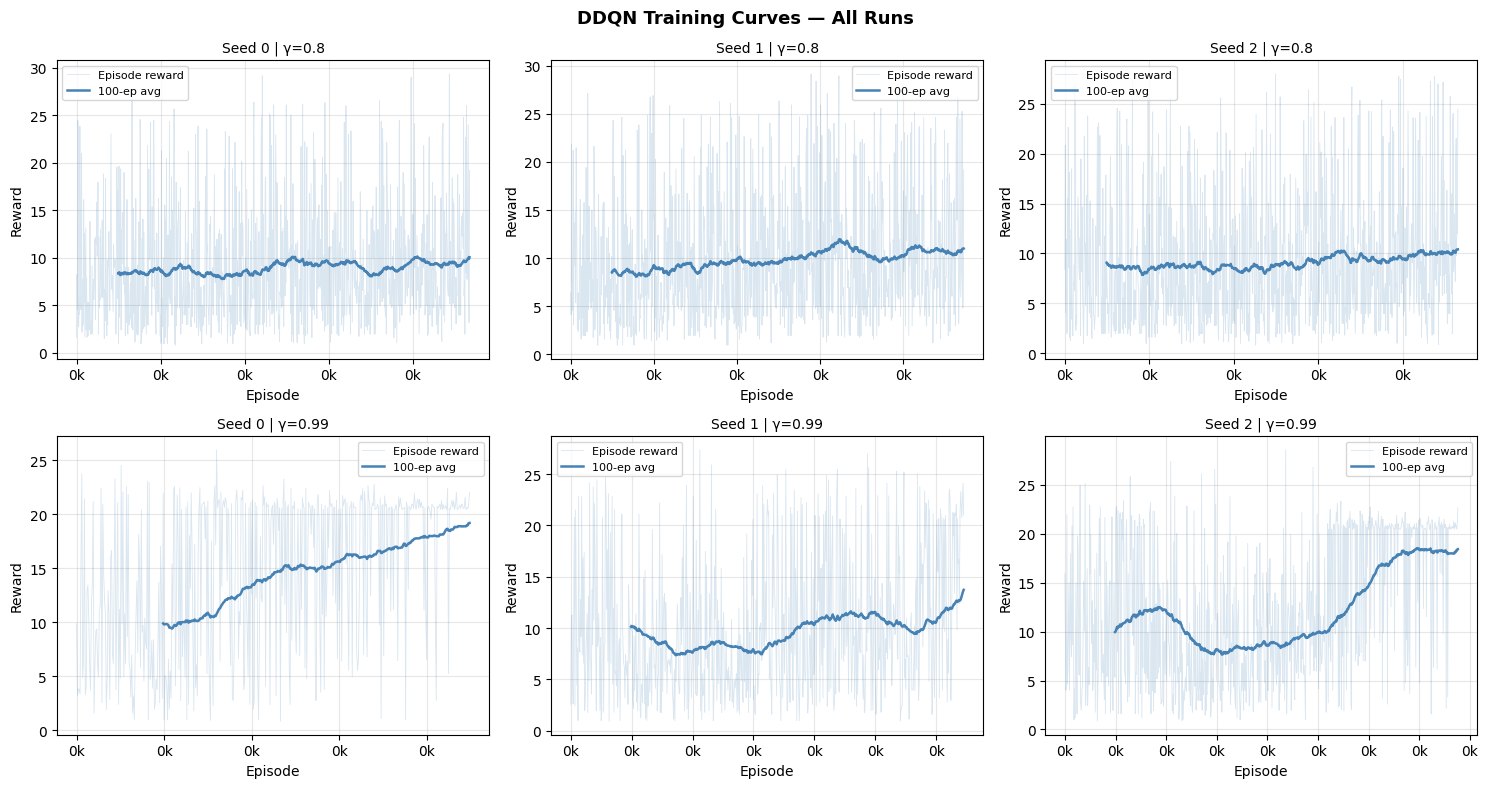

Saved → figures/training_curves_all.png


In [ ]:
# ── CELL: Training Curves from Checkpoints ──────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os, torch

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

def smooth(x, window=100):
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode='valid')

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)
axes = axes.flatten()

for ax, exp in zip(axes, experiments):
    run_name  = exp["run_id"]
    run_seed  = exp["seed"]
    run_gamma = exp["gamma"]

    ckpt_path = f"checkpoints/rl-ddqn/ddqn/{run_name}/best.pt"
    ckpt      = torch.load(ckpt_path, map_location="cpu")
    rewards   = np.array(ckpt["episode_rewards"])

    ax.plot(rewards, alpha=0.2, color="steelblue", linewidth=0.6, label="Episode reward")
    if len(rewards) >= 100:
        rolled = smooth(rewards, 100)
        ax.plot(range(99, len(rewards)), rolled, color="steelblue", linewidth=1.8, label="100-ep avg")

    ax.set_title(f"Seed {run_seed} | γ={run_gamma}", fontsize=10)
    ax.set_xlabel("Episode"); ax.set_ylabel("Reward")
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("DDQN Training Curves — All Runs", fontsize=13, fontweight="bold")
plt.tight_layout()

plt.savefig(f"{FIG_DIR}/training_curves_all.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved → {FIG_DIR}/training_curves_all.png")

In [15]:
all_detailed_results = []

for exp in experiments:
    run_seed = exp["seed"]
    run_name = exp["run_id"]
    run_gamma = exp["gamma"]

    print(f"\nEvaluating: Seed {run_seed} | Gamma {run_gamma}")

    # Initialize environment and agent with the run's specific gamma
    cfg = DQNConfig(gamma=run_gamma)
    env = make_env(run_seed)
    agent = DDQNAgent(env, cfg, run_seed)

    # Load weights
    checkpoint_path = f"checkpoints/rl-ddqn/ddqn/{run_name}/best.pt"
    ckpt = torch.load(checkpoint_path, map_location=device)
    agent.policy_net.load_state_dict(ckpt["policy_state_dict"])
    
    # Evaluation environment
    eval_env = make_env(run_seed + 1000)
    
    # Using your evaluate_with_crash_rate function
    # Modified to also return variance
    def evaluate_extended(env, policy_net, n_episodes, seed_offset):
        policy_net.eval()
        crashes, timeouts, rewards = 0, 0, []
        with torch.no_grad():
            for i in range(n_episodes):
                state, _ = env.reset(seed=seed_offset + i)
                state = to_state_tensor(state)
                total_r = 0.0
                for t in count():
                    action = policy_net(state).max(1).indices.view(1, 1)
                    obs, reward, terminated, truncated, info = env.step(action.item())
                    total_r += reward
                    if terminated:
                        if info.get("crashed", False): crashes += 1
                        break
                    if truncated:
                        timeouts += 1
                        break
                    state = to_state_tensor(obs)
                rewards.append(total_r)
        policy_net.train()
        
        return {
            "mean": stats.mean(rewards),
            "variance": stats.variance(rewards) if len(rewards) > 1 else 0,
            "std": stats.stdev(rewards) if len(rewards) > 1 else 0,
            "crash_rate": crashes / n_episodes,
            "timeout_rate": timeouts / n_episodes
        }

    stats_out = evaluate_extended(eval_env, agent.policy_net, n_episodes=50, seed_offset=run_seed + 2000)
    
    all_detailed_results.append({
        "seed": run_seed,
        "gamma": run_gamma,
        "mean_reward": stats_out["mean"],
        "variance": stats_out["variance"],
        "std_dev": stats_out["std"],
        "crash_ratio": stats_out["crash_rate"],
        "timeout_ratio": stats_out["timeout_rate"]
    })

    eval_env.close()
    env.close()
    


Evaluating: Seed 0 | Gamma 0.8


C:\Users\TALAE LOCAL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\transformers\utils\generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(



Evaluating: Seed 1 | Gamma 0.8

Evaluating: Seed 2 | Gamma 0.8

Evaluating: Seed 0 | Gamma 0.99

Evaluating: Seed 1 | Gamma 0.99

Evaluating: Seed 2 | Gamma 0.99


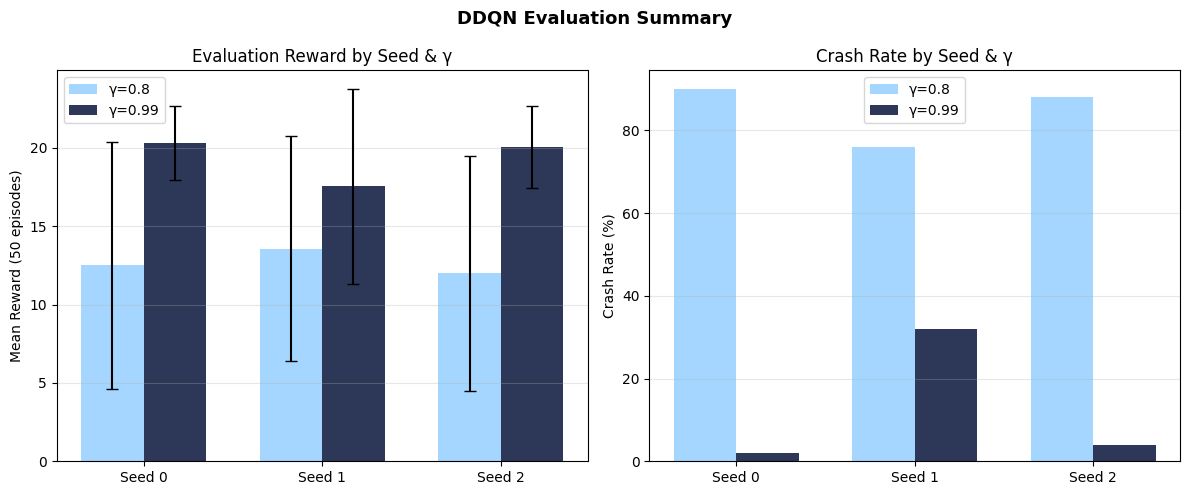

In [ ]:
# ──  Evaluation Summary Figures ────────────────────────────────────────
import pandas as pd

df = pd.DataFrame(all_detailed_results)
df.to_csv(f"{FIG_DIR}/ddqn_evaluation_summary.csv", index=False)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Left: mean reward grouped by gamma ──────────────────────────────────────
for i, (gamma, grp) in enumerate(df.groupby("gamma")):
    x     = np.arange(len(grp))
    label = f"γ={gamma}"
    color = ["#94CFFF", "#08143A"][i]
    axes[0].bar(x + i * 0.35, grp["mean_reward"], 0.35,
                yerr=grp["std_dev"], capsize=4,
                label=label, color=color, alpha=0.85)

axes[0].set_xticks(np.arange(3) + 0.175)
axes[0].set_xticklabels([f"Seed {s}" for s in df["seed"].unique()])
axes[0].set_ylabel("Mean Reward (50 episodes)")
axes[0].set_title("Evaluation Reward by Seed & γ")
axes[0].legend(); axes[0].grid(axis="y", alpha=0.3)

# ── Right: crash rate ────────────────────────────────────────────────────────
for i, (gamma, grp) in enumerate(df.groupby("gamma")):
    x = np.arange(len(grp))
    color = ["#94CFFF", "#08143A"][i]
    axes[1].bar(x + i * 0.35, grp["crash_ratio"] * 100, 0.35,
                label=f"γ={gamma}", color=color, alpha=0.85)

axes[1].set_xticks(np.arange(3) + 0.175)
axes[1].set_xticklabels([f"Seed {s}" for s in df["seed"].unique()])
axes[1].set_ylabel("Crash Rate (%)")
axes[1].set_title("Crash Rate by Seed & γ")
axes[1].legend(); axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("DDQN Evaluation Summary", fontsize=13, fontweight="bold")
plt.tight_layout()

plt.savefig(f"{FIG_DIR}/eval_summary.png", bbox_inches="tight", dpi=150)
plt.show()

In [17]:
import pandas as pd
df = pd.DataFrame(all_detailed_results)

# df.to_csv("detailed_experiment_results.csv", index=False)


# Print the raw table
print("\n### Detailed Experiment Results")
print(df.to_string(index=False))

# Group by Gamma to see the average effect of the hyperparameter
print("\n### Summary by Gamma")
summary = df.groupby("gamma")[["mean_reward", "std_dev", "crash_ratio"]].mean()
print(summary)


### Detailed Experiment Results
 seed  gamma  mean_reward  variance  std_dev  crash_ratio  timeout_ratio
    0   0.80    12.498315 61.791002 7.860725         0.90           0.10
    1   0.80    13.570940 51.333471 7.164738         0.76           0.24
    2   0.80    11.988544 56.293187 7.502879         0.88           0.12
    0   0.99    20.298772  5.492568 2.343623         0.02           0.98
    1   0.99    17.532079 38.671513 6.218642         0.32           0.68
    2   0.99    20.060548  6.880349 2.623042         0.04           0.96

### Summary by Gamma
       mean_reward   std_dev  crash_ratio
gamma                                    
0.80     12.685933  7.509447     0.846667
0.99     19.297133  3.728436     0.126667


## Failure Mode Analysis

Best run: {'seed': 0, 'gamma': 0.99, 'run_id': 'run_20260404-130041'}
Crashes: 8 / 200 (4.0%)
Timeouts: 192 / 200 (96.0%)


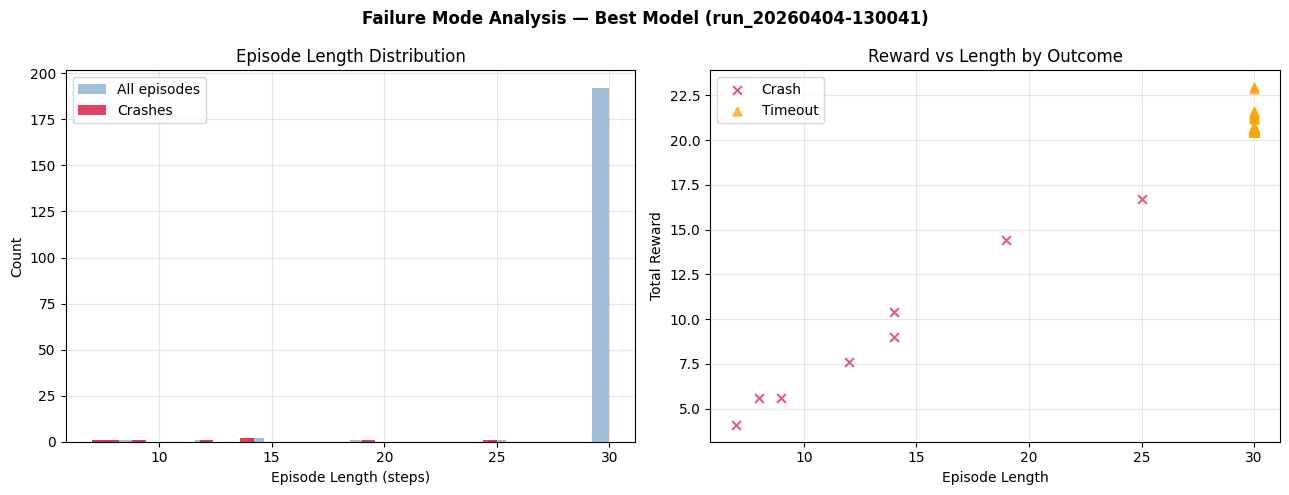

In [ ]:
# ── Failure Mode Analysis ──────────────────────────────────────────────
from itertools import count

# ── Pick the best run from df ────────────────────────────────────────────────
best_idx = df["mean_reward"].idxmax()
best_exp = experiments[best_idx]
print(f"Best run: {best_exp}")

cfg_best  = DQNConfig(gamma=best_exp["gamma"])
env_tmp   = make_env(best_exp["seed"])
best_agent = DDQNAgent(env_tmp, cfg_best, best_exp["seed"])
ckpt = torch.load(
    f"checkpoints/rl-ddqn/ddqn/{best_exp['run_id']}/best.pt",
    map_location=device
)
best_agent.policy_net.load_state_dict(ckpt["policy_state_dict"])
best_agent.policy_net.eval()
env_tmp.close()

# ── Collect crash episodes ────────────────────────────────────────────────────
N_FAIL_EPISODES = 200
crash_log = []   # list of dicts per episode

fail_env = make_env(best_exp["seed"] + 5000)

with torch.no_grad():
    for ep in range(N_FAIL_EPISODES):
        state, _ = fail_env.reset(seed=5000 + ep)
        state     = to_state_tensor(state)
        total_r   = 0.0
        ep_log    = []

        for t in count():
            action_idx = best_agent.policy_net(state).max(1).indices.view(1, 1)
            obs, reward, terminated, truncated, info = fail_env.step(action_idx.item())
            total_r += reward
            ep_log.append({
                "step": t, "reward": reward,
                "speed": obs[0, 1] if hasattr(obs, "__len__") else None,
                "crashed": info.get("crashed", False),
                "action": action_idx.item()
            })
            if terminated or truncated:
                crash_log.append({
                    "episode": ep,
                    "crashed": info.get("crashed", False),
                    "timeout": truncated,
                    "total_reward": total_r,
                    "length": t + 1,
                    "steps": ep_log,
                })
                break
            state = to_state_tensor(obs)

fail_env.close()

# ── Plot failure modes ────────────────────────────────────────────────────────
crash_eps   = [e for e in crash_log if e["crashed"]]
timeout_eps = [e for e in crash_log if e["timeout"]]
success_eps = [e for e in crash_log if not e["crashed"] and not e["timeout"]]

print(f"Crashes: {len(crash_eps)} / {N_FAIL_EPISODES} ({100*len(crash_eps)/N_FAIL_EPISODES:.1f}%)")
print(f"Timeouts: {len(timeout_eps)} / {N_FAIL_EPISODES} ({100*len(timeout_eps)/N_FAIL_EPISODES:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: survival length distribution
all_lengths = [e["length"] for e in crash_log]
crash_lengths = [e["length"] for e in crash_eps]
axes[0].hist(all_lengths, bins=30, alpha=0.5, color="steelblue", label="All episodes")
axes[0].hist(crash_lengths, bins=30, alpha=0.8, color="crimson", label="Crashes")
axes[0].set_xlabel("Episode Length (steps)"); axes[0].set_ylabel("Count")
axes[0].set_title("Episode Length Distribution"); axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: total reward vs length, coloured by outcome
for label, eps, color, marker in [
    ("Crash",   crash_eps,   "crimson",    "x"),
    ("Timeout", timeout_eps, "orange",     "^"),
    ("Success", success_eps, "steelblue",  "o"),
]:
    if eps:
        axes[1].scatter(
            [e["length"] for e in eps],
            [e["total_reward"] for e in eps],
            c=color, marker=marker, label=label, alpha=0.7, s=40
        )

axes[1].set_xlabel("Episode Length"); axes[1].set_ylabel("Total Reward")
axes[1].set_title("Reward vs Length by Outcome"); axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(f"Failure Mode Analysis — Best Model ({best_exp['run_id']})",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/failure_mode_analysis.png", bbox_inches="tight", dpi=150)
plt.show()

In [ ]:
# !pip install moviepy imageio[ffmpeg]

In [ ]:
# ── Record video of best model ─────────────────────────────────────────
import imageio
import numpy as np
from itertools import count

VIDEO_PATH = f"{FIG_DIR}/best_model_episode.mp4"
VIDEO_SEED = 9999
FPS        = 15

# Build a render-enabled env
video_env = make_env(VIDEO_SEED, render=True)   # render=True → rgb_array mode

state, _ = video_env.reset(seed=VIDEO_SEED)
state     = to_state_tensor(state)

frames = []
with torch.no_grad():
    for t in count():
        frame = video_env.render()
        frames.append(frame)

        action_idx = best_agent.policy_net(state).max(1).indices.view(1, 1)
        obs, reward, terminated, truncated, info = video_env.step(action_idx.item())

        if terminated or truncated:
            frames.append(video_env.render())   # grab last frame
            print(f"Episode ended at step {t+1} | crashed={info.get('crashed')} | truncated={truncated}")
            break
        state = to_state_tensor(obs)

video_env.close()

imageio.mimsave(VIDEO_PATH, frames, fps=FPS)
print(f"Video saved → {VIDEO_PATH}  ({len(frames)} frames, {len(frames)/FPS:.1f}s)")

Episode ended at step 30 | crashed=False | truncated=True


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 150) to (608, 160) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Video saved → figures/best_model_episode.mp4  (31 frames, 2.1s)


In [21]:
# Multiple episodes video grid
N_VIDEO_EPISODES = 20  # number of episodes to record
frames = []

for ep in range(N_VIDEO_EPISODES):
    state, _ = video_env.reset(seed=VIDEO_SEED + ep)
    state = to_state_tensor(state)

    with torch.no_grad():
        for t in count():
            frames.append(video_env.render())
            action_idx = best_agent.policy_net(state).max(1).indices.view(1, 1)
            obs, reward, terminated, truncated, info = video_env.step(action_idx.item())
            if terminated or truncated:
                frames.append(video_env.render())
                print(f"Ep {ep} ended | t={t+1} | crashed={info.get('crashed')}")
                break
            state = to_state_tensor(obs)

imageio.mimsave(VIDEO_PATH, frames, fps=FPS)

Ep 0 ended | t=30 | crashed=False
Ep 1 ended | t=30 | crashed=False
Ep 2 ended | t=30 | crashed=False
Ep 3 ended | t=30 | crashed=False
Ep 4 ended | t=30 | crashed=False
Ep 5 ended | t=30 | crashed=False
Ep 6 ended | t=30 | crashed=False
Ep 7 ended | t=30 | crashed=False
Ep 8 ended | t=5 | crashed=True
Ep 9 ended | t=30 | crashed=False
Ep 10 ended | t=30 | crashed=False
Ep 11 ended | t=30 | crashed=False
Ep 12 ended | t=30 | crashed=False
Ep 13 ended | t=30 | crashed=False
Ep 14 ended | t=30 | crashed=False
Ep 15 ended | t=30 | crashed=False
Ep 16 ended | t=30 | crashed=False
Ep 17 ended | t=30 | crashed=False
Ep 18 ended | t=30 | crashed=False


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 150) to (608, 160) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Ep 19 ended | t=30 | crashed=False
